# Optimization and Lagrange Multipliers

Source orientation: printed pages 597-598, PDF pages 615-616. This notebook is an original visualization-first lesson inspired by the structure of *Modern Robotics: Mechanics, Planning, and Control* by Kevin M. Lynch and Frank C. Park. It does not quote or reproduce textbook prose, exercises, screenshots, or page crops.

## Chapter Question

What does a multiplier say geometrically about constrained robot decisions?

This question is the thread for the chapter. The goal is not to memorize a list of formulas; it is to make the geometry inspectable. A robot mechanism is a physical machine, but the way we reason about it is through spaces, maps, constraints, tangents, and dual forces. The notebook keeps those objects visible. Every diagram and computation below is designed to answer a local question that a reader can check: what is moving, what is fixed, what map is being applied, what invariant should survive, and where can the model fail?

## Translation Guide

The source chapter or appendix is translated into computational language using these terms: objective, constraint, gradient, multiplier, KKT condition, active set, normal direction. The important conversions for this notebook are:

- At a constrained optimum, feasible tangent motion cannot reduce the objective.
- The multiplier scales a constraint normal to match objective gradient.
- Optimization shows up in planning, control allocation, and contact forces.

## Appendix D in Robotics Terms

Appendix D is short, but it carries a pattern that appears repeatedly in robot algorithms: choose the best motion, force, or timing variable while obeying a geometric rule. Write the design variable as `q`, the scalar objective as `f(q)`, and an equality constraint as `g(q) = 0`. Feasible first-order motion must lie in the tangent space of the constraint, which means `grad g(q*) dot delta q = 0`. At a constrained optimum, every feasible tangent direction has zero first-order improvement, so `grad f(q*)` has no tangent component left. The only direction it can occupy is the normal direction spanned by `grad g(q*)`. The multiplier `lambda` is the signed scale factor in `grad f(q*) + lambda grad g(q*) = 0`.

That statement is more than a calculus trick. In robotics, the same normal-versus-tangent split explains why a contact normal can supply a reaction force but cannot do arbitrary tangential work, why a closed-chain mechanism loses allowable velocity directions, and why a planner that hugs an obstacle boundary must reason about active constraints instead of treating every inequality as equally important. An inactive inequality has slack, so its normal does not participate in the stationarity equation. An active inequality behaves like an equality only when its multiplier has the correct sign. The signs and residuals therefore become debugging tools: a good candidate should satisfy the constraint, make the stationarity vector small, and leave the objective locally curved the right way along the feasible path.

The central habit is to name the representation and the invariant at the same time. Coordinates are useful only when we know what geometric object they represent. A column of joint angles may describe a point on a torus, a homogeneous transform may describe a rigid frame, and a matrix rank may reveal an instantaneous loss of motion. The notebook therefore pairs each formula with a small experiment: a plot, a residual, an ellipsoid, a path, a graph, or a constraint surface.

## Route Through the Notebook

1. Establish the objects and conventions needed for optimization and lagrange multipliers.
2. Build a concept dependency map so definitions have visible structure.
3. Generate the main visual lab: constraint gradients and multiplier geometry.
4. Run a compact worked example that exposes an invariant.
5. Try an applied lab that changes a parameter and asks what should remain true.
6. Finish with sanity checks that assert artifact existence, image variation, and numerical margins.

This is a standalone course notebook. The PDF can be useful for historical context and exercises, but the lesson here is complete without it. Definitions are restated in fresh language, examples are computed from scratch, and visuals are generated by course-local code. When the notebook mentions a source span, it is a navigation reference rather than a dependency for comprehension.

## Visualization Storyboard

| Concept | Representation | Artifact | Inspection target |
| --- | --- | --- | --- |
| concept dependency map | directed graph | `artifacts/appendix-d-optimization-and-lagrange-multipliers/figures/concept-dependency-map.png` | which definitions feed the chapter's computation |
| constraint gradients and multiplier geometry | level curves and active constraint normals | `artifacts/appendix-d-optimization-and-lagrange-multipliers/figures/optimization-lagrange-lab.png` | how optimality appears as aligned gradients under constraints |
| numeric invariant check | residual bar chart and JSON summary | `artifacts/appendix-d-optimization-and-lagrange-multipliers/figures/optimization-lagrange-checks.png` | small residuals, positive margins, or rank changes |

The first visual is a dependency map. It is intentionally simple: before computing anything, the reader should see which concepts support which later moves. The second visual is the main lab for this chapter. It turns the chapter's core geometry into something that can be inspected rather than imagined. The third visual is a numeric check: a residual, rank, eigenvalue, path length, or comparable margin that can be tested after the figure is built.

## Working Principles

The most reliable way to learn robotics geometry is to move between three views. The first view is symbolic: equations name maps and constraints. The second view is numerical: a small instance exposes scale, rank, conditioning, and residuals. The third view is visual: geometry becomes a shape, path, ellipsoid, cone, graph, or surface. This notebook keeps all three views close together. If a symbolic statement is correct, the numerical experiment should produce the expected small residual or positive margin. If a visual is meaningful, it should make a specific invariant or failure mode easier to see.

For optimization and lagrange multipliers, the relevant failure modes are not side details; they are part of the concept. Singularities, chart boundaries, rank loss, time-scaling limits, contact mode changes, and wheel constraints are all examples of geometry asserting itself. A robust robotics model does not pretend those edges are absent. It names them, draws them, and then tests a small case so the reader can recognize the issue in later code.

## Applied Lab

Draw level sets and a constraint curve, then check gradient alignment at a candidate optimum.

In the lab, vary one parameter at a time and predict the direction of change before running the code. For example, ask whether a rank should change, whether a path should lengthen, whether an eigenvalue should stay positive, whether a cone should widen, or whether a coordinate chart should approach a singular value. This prediction step is small, but it is what turns a figure into a mathematical instrument.

## Pitfalls To Watch

- A stationary point can be a maximum, minimum, or saddle.
- Inactive inequality constraints should not appear as active normals.

These pitfalls are deliberately operational. If a computation becomes confusing, check frame labels, units, rank, and the distinction between a physical object and its coordinates. Many robotics errors are not arithmetic mistakes; they are mismatches between a representation and the geometry it claims to encode.

## Takeaways

- Lagrange multipliers are geometry of normals.
- Robotics optimization is easier to debug by drawing feasible directions.

By the end of this notebook, the reader should be able to explain the chapter's main object, build a small computed example, interpret the generated visual artifact, and state at least one numerical sanity check that would catch an implementation mistake.

In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

HERE = Path.cwd().resolve()
BOOK_ROOT = next(
    parent for parent in [HERE, *HERE.parents]
    if (parent / "AGENTS.md").exists() and (parent / "Mordern Robotics.pdf").exists()
)
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib
from utils.validation import assert_artifact, image_stats

print(f"BOOK_ROOT={BOOK_ROOT}")


BOOK_ROOT=Modern-Robotics


In [2]:
CHAPTER = {
  "number": 17,
  "slug": "appendix-d-optimization-and-lagrange-multipliers",
  "title": "Optimization and Lagrange Multipliers",
  "notebook": "appendix-d-optimization-and-lagrange-multipliers.ipynb",
  "printed_start": 597,
  "printed_end": 598,
  "pdf_start": 615,
  "pdf_end": 616,
  "part_slug": "part-05-reference-appendices",
  "part_title": "Reference Appendices",
  "theme": "appendix",
  "visual_focus": "constraint gradients and multiplier geometry",
  "visual_kind": "level curves and active constraint normals",
  "artifact_stem": "optimization-lagrange",
  "inspection_target": "how optimality appears as aligned gradients under constraints",
  "question": "What does a multiplier say geometrically about constrained robot decisions?",
  "terms": [
    "objective",
    "constraint",
    "gradient",
    "multiplier",
    "KKT condition",
    "active set",
    "normal direction"
  ],
  "translation": [
    "At a constrained optimum, feasible tangent motion cannot reduce the objective.",
    "The multiplier scales a constraint normal to match objective gradient.",
    "Optimization shows up in planning, control allocation, and contact forces."
  ],
  "lab": "Draw level sets and a constraint curve, then check gradient alignment at a candidate optimum.",
  "pitfalls": [
    "A stationary point can be a maximum, minimum, or saddle.",
    "Inactive inequality constraints should not appear as active normals."
  ],
  "takeaways": [
    "Lagrange multipliers are geometry of normals.",
    "Robotics optimization is easier to debug by drawing feasible directions."
  ]
}

from utils.visuals import build_storyboard
storyboard = build_storyboard(CHAPTER)
storyboard

[{'concept': 'concept dependency map',
  'representation': 'directed graph',
  'artifact': 'artifacts/appendix-d-optimization-and-lagrange-multipliers/figures/concept-dependency-map.png',
  'inspection': "which definitions feed the chapter's computation"},
 {'concept': 'constraint gradients and multiplier geometry',
  'representation': 'level curves and active constraint normals',
  'artifact': 'artifacts/appendix-d-optimization-and-lagrange-multipliers/figures/optimization-lagrange-lab.png',
  'inspection': 'how optimality appears as aligned gradients under constraints'},
 {'concept': 'numeric invariant check',
  'representation': 'residual bar chart and JSON summary',
  'artifact': 'artifacts/appendix-d-optimization-and-lagrange-multipliers/figures/optimization-lagrange-checks.png',
  'inspection': 'small residuals, positive margins, or rank changes'}]

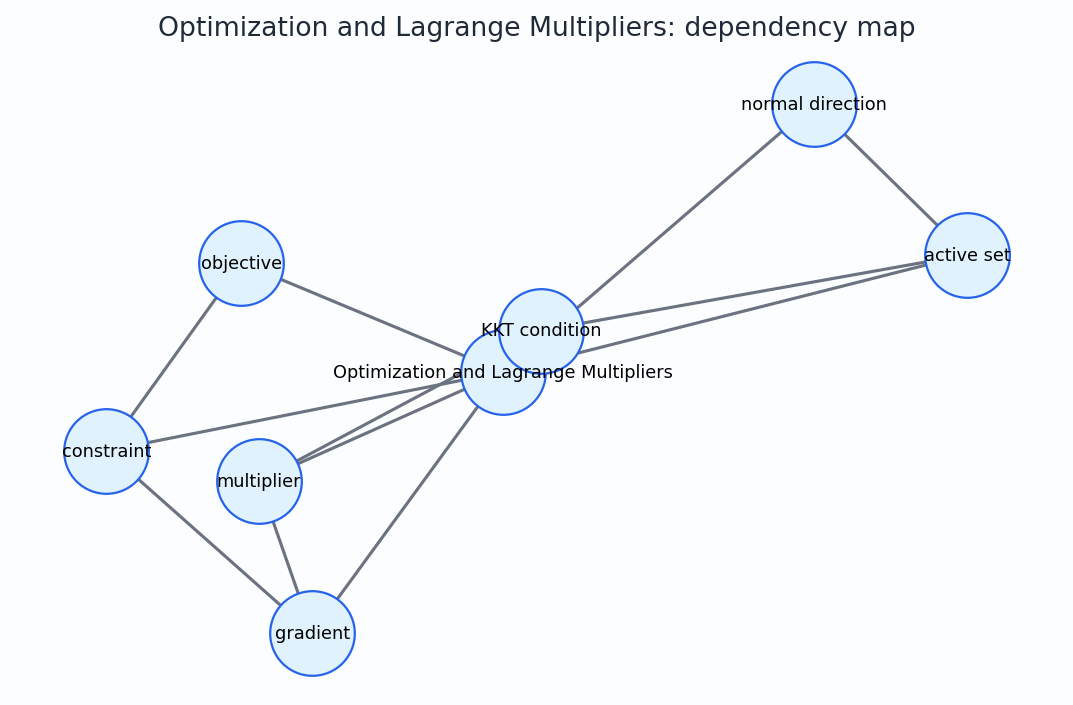

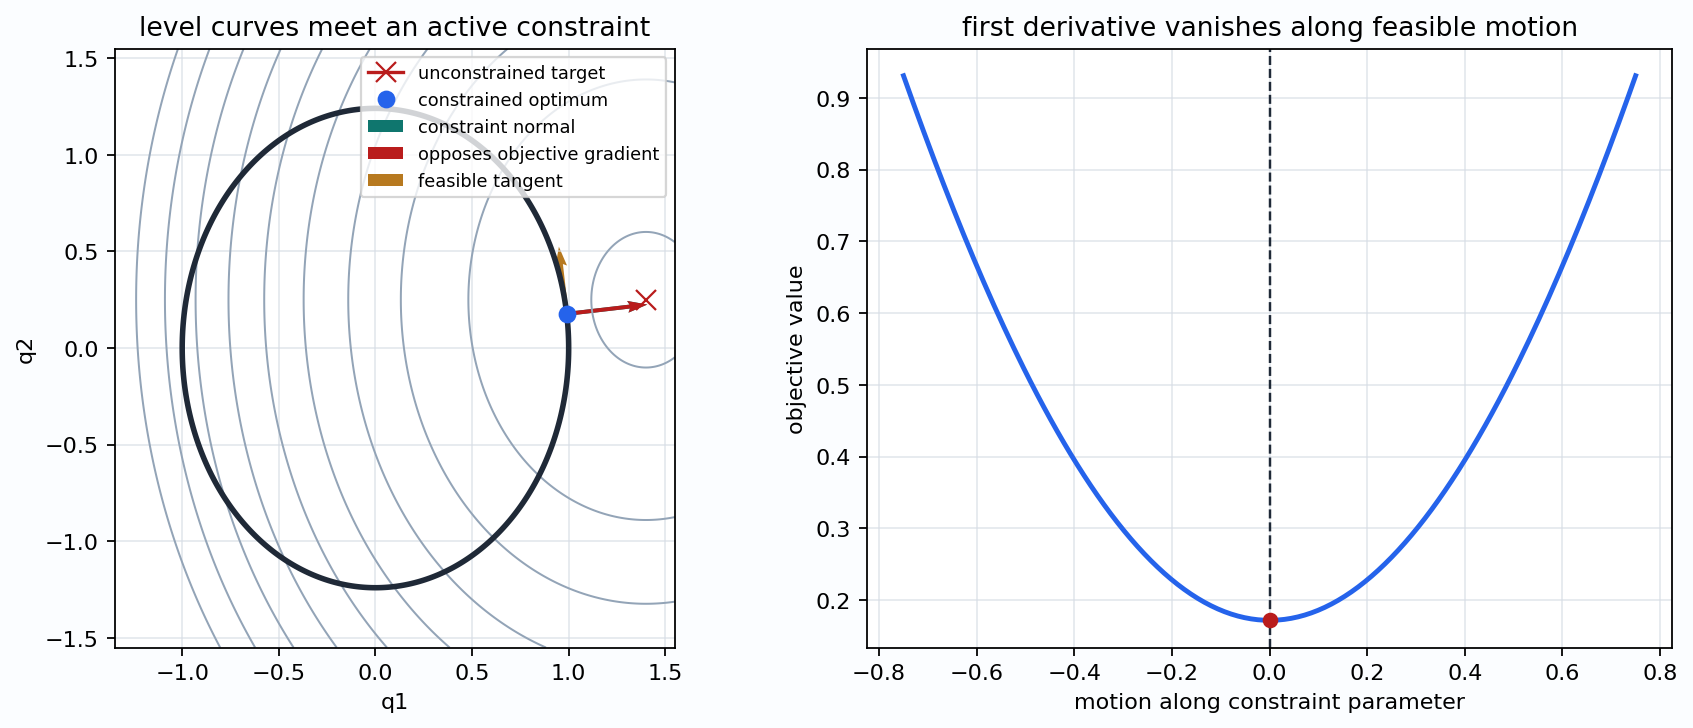

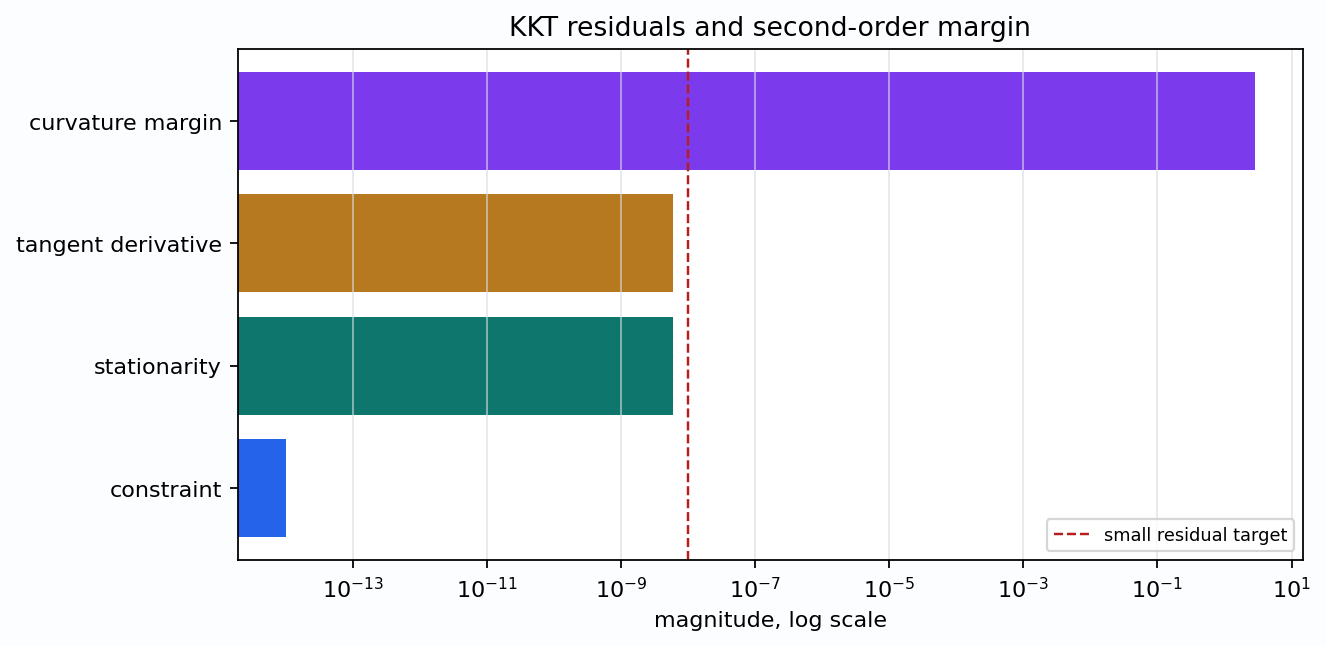

{'constraint_residual': 0.0,
 'stationarity_residual': 5.932392926589407e-09,
 'tangent_derivative_abs': 5.9323929241239526e-09,
 'curvature_margin': 2.8288687962396697,
 'lambda': 0.4144345161638351}

In [3]:
from scipy.optimize import minimize_scalar
from utils.visuals import build_chapter_visuals

outputs = build_chapter_visuals(CHAPTER)

OBJECTIVE_TARGET = np.array([1.4, 0.25])
OBJECTIVE_Y_WEIGHT = 0.65
CONSTRAINT_Y_WEIGHT = 0.65


def objective_for(q, target=OBJECTIVE_TARGET):
    q = np.asarray(q, dtype=float)
    target = np.asarray(target, dtype=float)
    diff = q - target
    return float(diff[0] ** 2 + OBJECTIVE_Y_WEIGHT * diff[1] ** 2)


def grad_objective_for(q, target=OBJECTIVE_TARGET):
    q = np.asarray(q, dtype=float)
    target = np.asarray(target, dtype=float)
    return np.array([2.0 * (q[0] - target[0]), 2.0 * OBJECTIVE_Y_WEIGHT * (q[1] - target[1])])


def constraint_value(q):
    q = np.asarray(q, dtype=float)
    return float(q[0] ** 2 + CONSTRAINT_Y_WEIGHT * q[1] ** 2 - 1.0)


def grad_constraint(q):
    q = np.asarray(q, dtype=float)
    return np.array([2.0 * q[0], 2.0 * CONSTRAINT_Y_WEIGHT * q[1]])


def point_on_constraint(theta):
    return np.array([np.cos(theta), np.sin(theta) / math.sqrt(CONSTRAINT_Y_WEIGHT)])


def solve_boundary_optimum(target=OBJECTIVE_TARGET):
    grid = np.linspace(0.0, 2.0 * math.pi, 960, endpoint=False)
    values = np.array([objective_for(point_on_constraint(t), target) for t in grid])
    t0 = float(grid[int(np.argmin(values))])
    window = 8.0 * 2.0 * math.pi / len(grid)
    result = minimize_scalar(
        lambda t: objective_for(point_on_constraint(t), target),
        bounds=(t0 - window, t0 + window),
        method="bounded",
        options={"xatol": 1e-13},
    )
    q = point_on_constraint(float(result.x))
    gf = grad_objective_for(q, target)
    gg = grad_constraint(q)
    lambda_value = -float(np.dot(gf, gg) / np.dot(gg, gg))
    tangent = np.array([-gg[1], gg[0]])
    tangent = tangent / np.linalg.norm(tangent)
    h = 1e-3
    curvature = (
        objective_for(point_on_constraint(result.x + h), target)
        - 2.0 * objective_for(q, target)
        + objective_for(point_on_constraint(result.x - h), target)
    ) / h**2
    return {
        "theta": float(result.x),
        "q": q,
        "lambda": lambda_value,
        "grad_f": gf,
        "grad_g": gg,
        "tangent": tangent,
        "constraint_residual": abs(constraint_value(q)),
        "stationarity_residual": float(np.linalg.norm(gf + lambda_value * gg)),
        "tangent_derivative": float(np.dot(gf, tangent)),
        "curvature_margin": float(curvature),
        "objective": objective_for(q, target),
    }


lagrange_solution = solve_boundary_optimum()
q_star = lagrange_solution["q"]
lambda_star = lagrange_solution["lambda"]

x = np.linspace(-1.35, 1.55, 320)
y = np.linspace(-1.55, 1.55, 320)
X, Y = np.meshgrid(x, y)
F = (X - OBJECTIVE_TARGET[0]) ** 2 + OBJECTIVE_Y_WEIGHT * (Y - OBJECTIVE_TARGET[1]) ** 2
G = X**2 + CONSTRAINT_Y_WEIGHT * Y**2 - 1.0

def draw_vector(ax, start, vector, color, label, scale=0.42):
    vector = np.asarray(vector, dtype=float)
    norm = np.linalg.norm(vector)
    if norm == 0:
        return
    direction = scale * vector / norm
    ax.quiver(
        start[0],
        start[1],
        direction[0],
        direction[1],
        angles="xy",
        scale_units="xy",
        scale=1,
        width=0.007,
        color=color,
        label=label,
    )

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7), facecolor="#fbfdff")
levels = np.linspace(float(F.min()) + 0.08, float(F.max()) * 0.72, 10)
axes[0].contour(X, Y, F, levels=levels, colors="#93a4b7", linewidths=0.9)
axes[0].contour(X, Y, G, levels=[0.0], colors="#1f2937", linewidths=2.5)
axes[0].plot(OBJECTIVE_TARGET[0], OBJECTIVE_TARGET[1], marker="x", markersize=9, color="#b91c1c", label="unconstrained target")
axes[0].plot(q_star[0], q_star[1], "o", color="#2563eb", markersize=7, label="constrained optimum")
draw_vector(axes[0], q_star, lagrange_solution["grad_g"], "#0f766e", "constraint normal")
draw_vector(axes[0], q_star, -lagrange_solution["grad_f"], "#b91c1c", "opposes objective gradient")
draw_vector(axes[0], q_star, lagrange_solution["tangent"], "#b7791f", "feasible tangent", scale=0.35)
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_xlabel("q1")
axes[0].set_ylabel("q2")
axes[0].set_title("level curves meet an active constraint")
axes[0].grid(True, color="#d7dde5", linewidth=0.7, alpha=0.75)
axes[0].legend(loc="upper right", fontsize=8)

offsets = np.linspace(-0.75, 0.75, 220)
along_constraint = np.array([objective_for(point_on_constraint(lagrange_solution["theta"] + s)) for s in offsets])
axes[1].plot(offsets, along_constraint, color="#2563eb", linewidth=2.2)
axes[1].axvline(0.0, color="#1f2937", linestyle="--", linewidth=1.1)
axes[1].scatter([0.0], [lagrange_solution["objective"]], color="#b91c1c", zorder=4)
axes[1].set_xlabel("motion along constraint parameter")
axes[1].set_ylabel("objective value")
axes[1].set_title("first derivative vanishes along feasible motion")
axes[1].grid(True, color="#d7dde5", linewidth=0.7, alpha=0.75)
fig.tight_layout()
lagrange_lab_path = save_matplotlib(fig, CHAPTER["slug"], "figures", "optimization-lagrange-lab.png")
plt.close(fig)

lagrange_metrics = {
    "constraint_residual": float(lagrange_solution["constraint_residual"]),
    "stationarity_residual": float(lagrange_solution["stationarity_residual"]),
    "tangent_derivative_abs": float(abs(lagrange_solution["tangent_derivative"])),
    "curvature_margin": float(lagrange_solution["curvature_margin"]),
    "lambda": float(lambda_star),
}

fig, ax = plt.subplots(figsize=(8.4, 4.2), facecolor="#fbfdff")
residual_names = ["constraint", "stationarity", "tangent derivative", "curvature margin"]
residual_values = [
    max(lagrange_metrics["constraint_residual"], 1e-14),
    max(lagrange_metrics["stationarity_residual"], 1e-14),
    max(lagrange_metrics["tangent_derivative_abs"], 1e-14),
    max(lagrange_metrics["curvature_margin"], 1e-14),
]
ax.barh(residual_names, residual_values, color=["#2563eb", "#0f766e", "#b7791f", "#7c3aed"])
ax.set_xscale("log")
ax.axvline(1e-8, color="#b91c1c", linestyle="--", linewidth=1.1, label="small residual target")
ax.set_xlabel("magnitude, log scale")
ax.set_title("KKT residuals and second-order margin")
ax.grid(True, axis="x", color="#d7dde5", linewidth=0.7, alpha=0.75)
ax.legend(fontsize=8)
fig.tight_layout()
lagrange_checks_path = save_matplotlib(fig, CHAPTER["slug"], "figures", "optimization-lagrange-checks.png")
plt.close(fig)

outputs["figures"] = [outputs["figures"][0], lagrange_lab_path, lagrange_checks_path]
outputs["metrics"] = lagrange_metrics
outputs["checks"] = save_json({"metrics": lagrange_metrics}, CHAPTER["slug"], "checks", "final-sanity.json")
for artifact in outputs["figures"]:
    display_artifact(artifact, width=760)
outputs["metrics"]


## Worked Example

The worked example below uses the same two-dimensional problem as the visual lab: minimize a weighted distance to a desired joint-space point while staying on an elliptical equality constraint. The unconstrained target is deliberately outside the feasible set, so the optimum must live on the boundary. The useful checks are geometric rather than merely numerical: the constraint residual should be tiny, `grad f + lambda grad g` should nearly vanish, and the directional derivative along the feasible tangent should be zero. Those three facts say that the objective gradient has been converted into a constraint normal, which is the core message of Appendix D.


In [4]:
worked_example = {
    "q_star": q_star.round(8).tolist(),
    "lambda": float(lambda_star),
    "objective_at_q_star": float(lagrange_solution["objective"]),
    "constraint_residual": float(lagrange_solution["constraint_residual"]),
    "stationarity_residual": float(lagrange_solution["stationarity_residual"]),
    "tangent_derivative": float(lagrange_solution["tangent_derivative"]),
    "curvature_margin": float(lagrange_solution["curvature_margin"]),
}
assert worked_example["constraint_residual"] < 1e-9
assert worked_example["stationarity_residual"] < 1e-7
assert abs(worked_example["tangent_derivative"]) < 1e-7
assert worked_example["curvature_margin"] > 0.0
worked_example


{'q_star': [0.98979485, 0.17674908],
 'lambda': 0.4144345161638351,
 'objective_at_q_star': 0.17175596803687276,
 'constraint_residual': 0.0,
 'stationarity_residual': 5.932392926589407e-09,
 'tangent_derivative': 5.9323929241239526e-09,
 'curvature_margin': 2.8288687962396697}

## Applied Lab

The applied lab changes the target point and asks whether the inequality form of the same constraint is active. If the target already lies inside `g(q) <= 0`, the best feasible point is the target itself and the multiplier should be zero because the boundary normal is irrelevant. If the target lies outside, the boundary becomes active and the equality calculation above applies. This is the active-set habit used in robot planning and contact: first decide which constraints actually touch the solution, then check the signs and residuals for only those constraints.


In [5]:
def solve_inequality_case(target):
    target = np.asarray(target, dtype=float)
    if constraint_value(target) <= 0.0:
        return {
            "target": target.round(6).tolist(),
            "q": target.round(6).tolist(),
            "active": False,
            "lambda": 0.0,
            "constraint_value": float(constraint_value(target)),
            "stationarity_residual": 0.0,
        }
    solution = solve_boundary_optimum(target)
    q = solution["q"]
    return {
        "target": target.round(6).tolist(),
        "q": q.round(6).tolist(),
        "active": True,
        "lambda": float(solution["lambda"]),
        "constraint_value": float(constraint_value(q)),
        "stationarity_residual": float(solution["stationarity_residual"]),
    }

lab_cases = {
    "inactive_inside_target": solve_inequality_case(np.array([0.35, 0.15])),
    "active_outside_target": solve_inequality_case(np.array([1.35, -0.45])),
}
lab_summary = {
    "theme": CHAPTER["theme"],
    "cases": lab_cases,
    "active_case_stationarity_residual": lab_cases["active_outside_target"]["stationarity_residual"],
}
assert lab_cases["inactive_inside_target"]["active"] is False
assert lab_cases["inactive_inside_target"]["lambda"] == 0.0
assert lab_cases["active_outside_target"]["active"] is True
assert lab_cases["active_outside_target"]["stationarity_residual"] < 1e-7
lab_summary


{'theme': 'appendix',
 'cases': {'inactive_inside_target': {'target': [0.35, 0.15],
   'q': [0.35, 0.15],
   'active': False,
   'lambda': 0.0,
   'constraint_value': -0.8628750000000001,
   'stationarity_residual': 0.0},
  'active_outside_target': {'target': [1.35, -0.45],
   'q': [0.965734, -0.321911],
   'active': True,
   'lambda': 0.39790021514487756,
   'constraint_value': -1.1102230246251565e-16,
   'stationarity_residual': 7.472367422373729e-08}},
 'active_case_stationarity_residual': 7.472367422373729e-08}

## Sanity Checks

The final cell asserts that the generated artifacts exist, are large enough to be useful, and have nontrivial pixel variation. It also checks the Appendix D numerical invariants directly: feasibility, stationarity, zero tangent derivative, and a positive local curvature margin along the constraint. The resulting JSON file is saved under the appendix artifact subtree so the notebook leaves a machine-checkable trace.


In [6]:
artifact_stats = {}
for artifact in outputs["figures"]:
    resolved = assert_artifact(artifact)
    stats = image_stats(resolved)
    assert stats["pixel_std"] > 2.0, f"low variation image: {resolved}"
    artifact_stats[resolved.name] = stats

assert outputs["metrics"]["constraint_residual"] < 1e-9
assert outputs["metrics"]["stationarity_residual"] < 1e-7
assert outputs["metrics"]["tangent_derivative_abs"] < 1e-7
assert outputs["metrics"]["curvature_margin"] > 0.0

sanity = {
    "chapter": CHAPTER["slug"],
    "metrics": outputs["metrics"],
    "worked_example": worked_example,
    "lab_summary": lab_summary,
    "artifact_stats": artifact_stats,
}
outputs["checks"] = save_json(sanity, CHAPTER["slug"], "checks", "final-sanity.json")
assert_artifact(outputs["checks"], min_size=100)
display_artifact(outputs["checks"])
sanity


{'chapter': 'appendix-d-optimization-and-lagrange-multipliers',
 'metrics': {'constraint_residual': 0.0,
  'stationarity_residual': 5.932392926589407e-09,
  'tangent_derivative_abs': 5.9323929241239526e-09,
  'curvature_margin': 2.8288687962396697,
  'lambda': 0.4144345161638351},
 'worked_example': {'q_star': [0.98979485, 0.17674908],
  'lambda': 0.4144345161638351,
  'objective_at_q_star': 0.17175596803687276,
  'constraint_residual': 0.0,
  'stationarity_residual': 5.932392926589407e-09,
  'tangent_derivative': 5.9323929241239526e-09,
  'curvature_margin': 2.8288687962396697},
 'lab_summary': {'theme': 'appendix',
  'cases': {'inactive_inside_target': {'target': [0.35, 0.15],
    'q': [0.35, 0.15],
    'active': False,
    'lambda': 0.0,
    'constraint_value': -0.8628750000000001,
    'stationarity_residual': 0.0},
   'active_outside_target': {'target': [1.35, -0.45],
    'q': [0.965734, -0.321911],
    'active': True,
    'lambda': 0.39790021514487756,
    'constraint_value': -1.1